1. Initializing EPRI J1 Digital Twin...
2. Generating Abuja Solar & Demand Profiles...
3. Executing 24-Hour Power Flow Simulation...
✅ Simulation Complete! Generating VPP Dashboard...


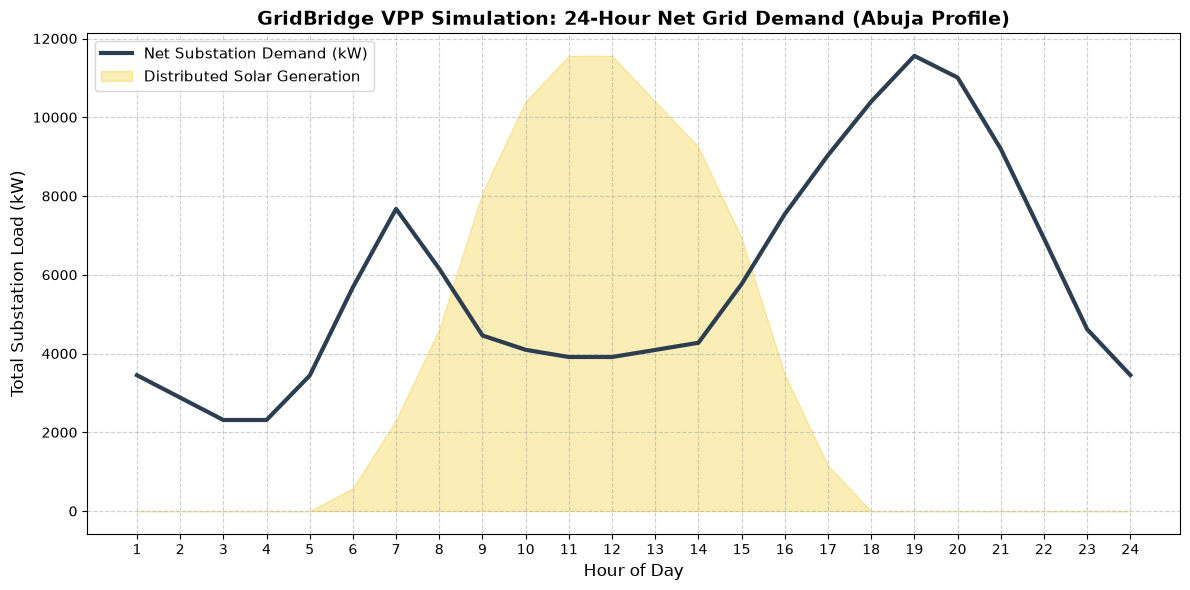

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dss import dss

print("1. Initializing EPRI J1 Digital Twin...")
dss_file = r"C:/Program Files/OpenDSS/EPRITestCircuits/epri_dpv/J1/Master_withPV.dss"
dss.Text.Command = f'redirect "{dss_file}"'

# 2. Define Abuja-Specific 24-Hour Profiles
print("2. Generating Abuja Solar & Demand Profiles...")
hours = np.arange(1, 25)

# Synthetic Abuja Solar Irradiance Curve
solar_curve = [0, 0, 0, 0, 0, 0.05, 0.2, 0.4, 0.7, 0.9, 1.0, 1.0, 
               0.9, 0.8, 0.6, 0.3, 0.1, 0, 0, 0, 0, 0, 0, 0]

# Synthetic Demand Profile
demand_curve = [0.3, 0.25, 0.2, 0.2, 0.3, 0.5, 0.7, 0.6, 0.5, 0.5, 0.5, 0.5, 
                0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 0.95, 0.8, 0.6, 0.4, 0.3]

# 3. Inject Profiles into OpenDSS Engine
dss.Text.Command = f"New LoadShape.AbujaSolar npts=24 interval=1 mult={solar_curve}"
dss.Text.Command = f"New LoadShape.AbujaDemand npts=24 interval=1 mult={demand_curve}"

# BULLETPROOF FIX: Use 'Batchedit' to assign the shapes to all objects instantly. No Python loops.
dss.Text.Command = "Batchedit PVSystem..* daily=AbujaSolar"
dss.Text.Command = "Batchedit Load..* daily=AbujaDemand"

# 4. Run 24-Hour Time-Series Simulation
print("3. Executing 24-Hour Power Flow Simulation...")
dss.Text.Command = "Set Mode=Daily stepsize=1h number=1"

net_grid_demand = []
for hour in hours:
    dss.ActiveCircuit.Solution.Solve()
    # Record total power drawn from the main substation (in kW)
    total_kw = -1 * dss.ActiveCircuit.TotalPower[0] 
    net_grid_demand.append(total_kw)

print("✅ Simulation Complete! Generating VPP Dashboard...")

# 5. Visualize the VPP Impact (Operational Dashboard)
plt.figure(figsize=(12, 6))
plt.plot(hours, net_grid_demand, label='Net Substation Demand (kW)', color='#2c3e50', linewidth=3)
plt.fill_between(hours, 0, [s * max(net_grid_demand) for s in solar_curve], 
                 color='#f1c40f', alpha=0.3, label='Distributed Solar Generation')

plt.title("GridBridge VPP Simulation: 24-Hour Net Grid Demand (Abuja Profile)", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Total Substation Load (kW)", fontsize=12)
plt.xticks(hours)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
import requests
import pandas as pd
import numpy as np
import json

print("Fetching live solar irradiance for Abuja, Nigeria...")

# 1. Fetch real hourly solar radiation for Abuja (Lat: 9.07, Lon: 7.39)
url = "https://api.open-meteo.com/v1/forecast?latitude=9.07&longitude=7.39&hourly=shortwave_radiation&timezone=Africa/Lagos&forecast_days=1"
response = requests.get(url)
weather_data = response.json()

# 2. Extract the 24-hour solar array
# Shortwave radiation is in W/m². We scale it to our 850 kWp Mini-grid.
# Assuming roughly 80% system efficiency (Performance Ratio) and standard 1000 W/m² test conditions.
raw_radiation = weather_data['hourly']['shortwave_radiation']
pv_kw = [round((rad / 1000) * 850 * 0.8, 1) for rad in raw_radiation]

# 3. Create a realistic African mini-grid load profile (kW)
# Morning peak (getting ready for work), massive evening peak (lighting/cooling), low midday load.
base_load = [
    120, 115, 110, 105, 105, 115,  # 00:00 - 05:00 (Night base)
    140, 180, 195, 170, 160, 155,  # 06:00 - 11:00 (Morning peak)
    150, 145, 150, 155, 165, 190,  # 12:00 - 17:00 (Midday)
    250, 280, 260, 220, 180, 140   # 18:00 - 23:00 (Evening peak)
]

# Add a tiny bit of random noise to make the load look real (like actual SCADA data)
np.random.seed(42) # Seed for consistency
noisy_load = [round(l * np.random.uniform(0.95, 1.05), 1) for l in base_load]

# 4. Calculate Battery State of Charge (SOC)
# Assuming a 1200 kWh battery starting the day at 40% SOC
battery_capacity_kwh = 1200
current_soc_kwh = battery_capacity_kwh * 0.40
soc_percentages = []
grid_exchange = []

for hour in range(24):
    # Calculate surplus or deficit
    net_power = pv_kw[hour] - noisy_load[hour]
    
    # Update battery
    if net_power > 0: # Surplus: Charge battery
        current_soc_kwh = min(battery_capacity_kwh, current_soc_kwh + net_power)
        grid_export = max(0, net_power - (battery_capacity_kwh - current_soc_kwh))
    else: # Deficit: Discharge battery (down to 20% minimum safety reserve)
        available_discharge = current_soc_kwh - (battery_capacity_kwh * 0.20)
        discharge_amount = min(abs(net_power), available_discharge)
        current_soc_kwh -= discharge_amount
        grid_export = -(abs(net_power) - discharge_amount) # Negative means importing from AEDC grid
        
    soc_percentages.append(round((current_soc_kwh / battery_capacity_kwh) * 100, 1))
    grid_exchange.append(round(grid_export, 1))

# 5. Pack everything into a DataFrame
df_vpp = pd.DataFrame({
    'Time': [f"{str(h).zfill(2)}:00" for h in range(24)],
    'PV_Generation_kW': pv_kw,
    'Local_Demand_kW': noisy_load,
    'Battery_SOC_%': soc_percentages,
    'Grid_Exchange_kW': grid_exchange
})

display(df_vpp.head(24))

# ==========================================
# EXPORT TO JSON FOR HTML
# ==========================================
export_path = r"C:\Users\Smarterise PC\Projects\PoC\data\vpp_daily_profile.json"
df_vpp.to_json(export_path, orient="records", indent=4)
print(f"\n✅ 24-Hour VPP Dispatch Profile exported successfully to:\n{export_path}")

Fetching live solar irradiance for Abuja, Nigeria...


,Time,PV_Generation_kW,Local_Demand_kW,Battery_SOC_%,Grid_Exchange_kW
0,00:00,0.0,118.5,30.1,-0.0
1,01:00,0.0,120.2,20.1,-0.0
2,02:00,0.0,112.6,20.0,-111.3
3,03:00,0.0,106.0,20.0,-106.0
4,04:00,0.0,101.4,20.0,-101.4
5,05:00,0.0,111.0,20.0,-111.0
6,06:00,0.0,133.8,20.0,-133.8
7,07:00,1.4,186.6,20.0,-185.2
8,08:00,59.8,197.0,20.0,-137.2
9,09:00,51.7,173.5,20.0,-121.8



✅ 24-Hour VPP Dispatch Profile exported successfully to:
C:\Users\Smarterise PC\Projects\PoC\data\vpp_daily_profile.json
